# Hydrologic Parameter Preparation for Machine Learning

## Introduction

This notebook outlines the systematic, multi-stage process for cleaning, filtering, and preparing calibrated ModClark hydrologic parameters—specifically the **time of concentration ($T_c$)** and the **storage coefficient ($R$)**. The data originates from thousands of storm events across hundreds of watersheds.

The primary goal is to engineer a high-quality, robust, and reliable feature set to train a machine learning model. This model will ultimately predict $T_c$ and $R$ for ungauged basins, making this preparatory work a critical foundation for the project's success.

---

### Analysis Workflow

The workflow is divided into four main stages, each building upon the last to progressively refine the dataset.

1.  **Initial Performance Assessment:** We begin by evaluating the quality of all initial parameter calibrations using the **Nash-Sutcliffe Efficiency (NSE)**. A logistic regression model is used to systematically analyze the relationship between various storm characteristics and model performance. This diagnostic step helps identify the primary drivers of poor model fits, which could indicate systematic data quality or modeling issues.

2.  **Data Cleaning and Filtering:** A rigorous, multi-step filtering protocol is applied to the event data. This involves:
    * First, a hard performance threshold is applied, retaining only events with **NSE >= 0.5**.
    * Outlier events within each watershed are identified and removed using the robust **Interquartile Range (IQR)** method on both the $T_c$ and $R$ parameters.
    * Finally, any watershed with fewer than five high-quality events remaining after these filters is excluded to ensure statistical robustness in subsequent steps.

3.  **Investigating Temporal Trends:** We statistically assess whether year-to-year changes in land use have a significant impact on the calibrated $T_c$ and $R$ values for each watershed. This is tested using two methods: one-way **ANOVA** and **Pearson correlation analysis** against the percentage of developed land. The **null hypotheses ($H_0$)** for these tests are:
    * **For ANOVA:** The mean $T_c$ (or $R$) for a given watershed is the same across all years.
    * **For Correlation:** There is no linear relationship between the percentage of developed land and the mean yearly $T_c$ (or $R$).

    Rejecting either null hypothesis (p < 0.05) provides the statistical evidence needed to justify aggregating parameters on a yearly basis for that watershed.

4.  **Final Data Aggregation:** Based on the results of the temporal analysis, the final master dataset is created. A final quality check is performed before any averaging:
    * **Coefficient of Variation (CV) Check:** Before calculating a final average for any group (either an entire watershed or a single year within a watershed), its CV is checked. If the CV for either $T_c$ or $R$ is too high (e.g., > 0.5), that group is considered too dispersed and is discarded from the final dataset.
    * **Aggregation:**
        * For watersheds where a significant temporal trend was detected, parameters are aggregated on a **yearly basis**.
        * For all other watersheds, a single, long-term **watershed-wide average** is computed.

#### 1. Initial Performance Assessment

In [1]:
from pathlib import Path

# Custom Modules
PROJECT_ROOT = Path.cwd().parent.parent

In [2]:
# Load files
import pandas as pd

events_path = PROJECT_ROOT / "data/gold/tabular/optmized_params/optmized_1000_tz_dataset.csv"
storm_characteristics_path = PROJECT_ROOT / "data/gold/tabular/detected_storm_events_tz_offset_filtered.parquet"
land_cover_use_path = PROJECT_ROOT / "data/gold/tabular/land_cover_percentages.csv"

storm_characteristics = pd.read_parquet(storm_characteristics_path)
df_events = pd.read_csv(events_path, dtype={'ws_id': str, 'event_id': str})
df_events = df_events.merge(storm_characteristics.drop(columns='ws_id'), on='storm_id', how='left')
df_events = df_events.rename(columns={'nse': 'NSE', 'tc_hr': 'Tc', 'r_hr': 'R'})
df_land_cover = pd.read_csv(land_cover_use_path, dtype={'stnid': str})
df_land_cover = df_land_cover.rename(columns={'stnid': 'ws_id'})

In [3]:
storm_characteristics.iloc[0]

event_start                 2018-05-06 01:00:00+00:00
event_end                   2018-05-08 20:45:00+00:00
month                                               5
ppt_start                   2018-05-06 01:30:00+00:00
ppt_end                     2018-05-06 05:45:00+00:00
total_precipitation_mm                           5.08
total_ppt_after_peak_mm                           0.0
response_min                                     30.0
ppt_dutation_min                                  270
event_duration_min                               4080
peak_quickflow                              56.947725
ppt_temporal_variability                     0.000408
ppt_spatial_variability                           NaN
n_ppt_stations                                      1
missing_streamflow                                  0
ppt_prior_14d                                 0.13081
ppt_prior_7d                                 0.067564
ppt_prior_3d                                 0.049784
ppt_prior_24h               

--- Overall Event Quality Summary ---
nse_category
Unacceptable (NSE <= 0)        681
Acceptable (0 < NSE <= 0.5)    103
Good (0.5 < NSE <= 0.75)        81
Very Good (NSE > 0.75)          65
Name: count, dtype: int64




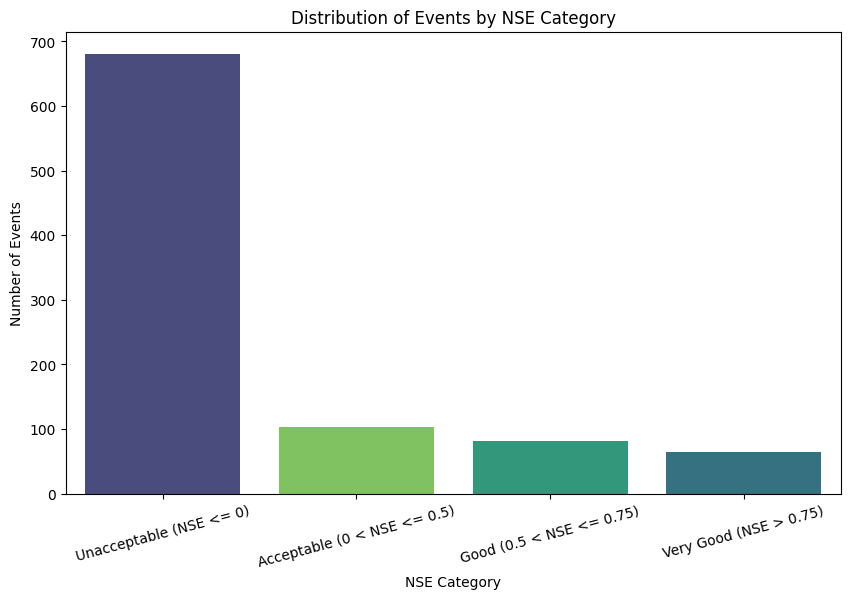

--- Events per Watershed Summary ---
Number of watersheds with at least one acceptable event: 110

Statistics for the number of acceptable events per watershed:
count    110.00
mean       2.26
std        1.87
min        1.00
25%        1.00
50%        1.00
75%        3.00
max       10.00
Name: n_acceptable_events, dtype: float64

--- Analyzing Drivers of Unacceptable Model Fits (NSE <= 0) ---

Top 10 characteristics driving model performance (from Logistic Regression):
                     feature  coefficient  abs_coefficient
6             peak_quickflow     3.506526         3.506526
5         event_duration_min     2.140013         2.140013
4           ppt_dutation_min    -0.381571         0.381571
9             n_ppt_stations     0.363184         0.363184
1     total_precipitation_mm    -0.276766         0.276766
16              ppt_prior_3h     0.267813         0.267813
8    ppt_spatial_variability    -0.205944         0.205944
7   ppt_temporal_variability    -0.191507         0.19

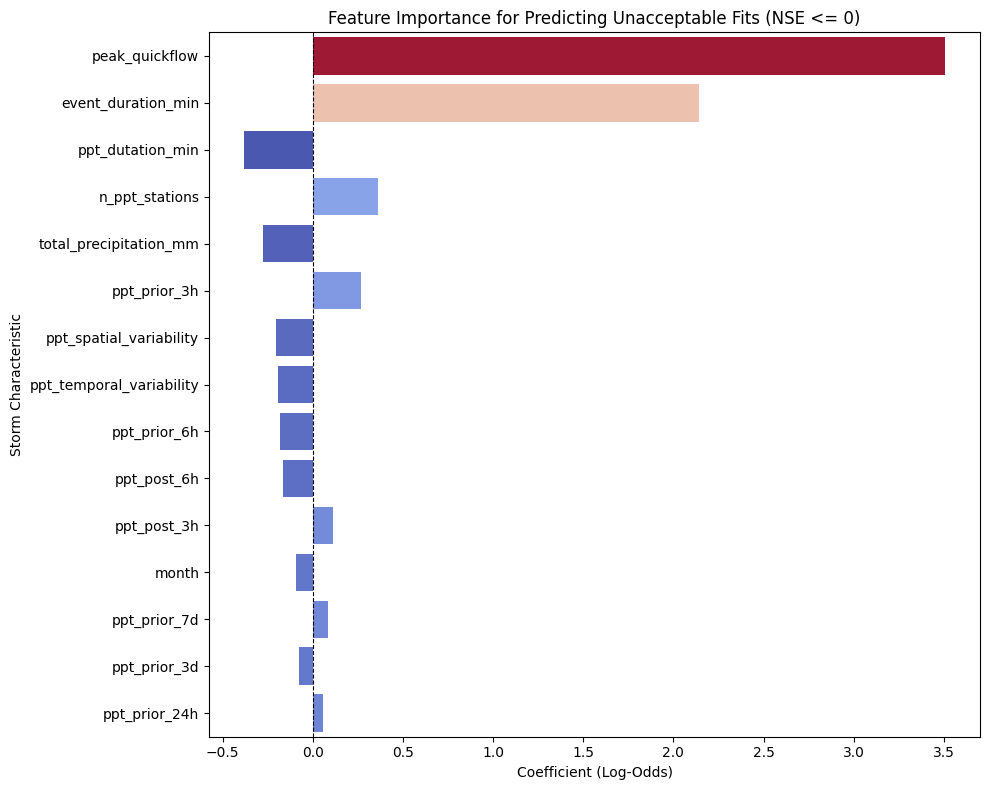


--- Final Assessment ---
Total events processed: 930
Number of unacceptable events (NSE <= 0): 681 (73.2%)
Number of suitable events for next steps (NSE > 0): 249 (26.8%)


In [55]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

#-------------------------------------------------------------------------------
## Step 1: Categorize NSE and Initial Summaries
#-------------------------------------------------------------------------------

# Define the function to categorize NSE
def categorize_nse(nse):
    if nse > 0.75:
        return 'Very Good (NSE > 0.75)'
    elif 0.50 < nse <= 0.75:
        return 'Good (0.5 < NSE <= 0.75)'
    elif 0.0 < nse <= 0.50:
        return 'Acceptable (0 < NSE <= 0.5)'
    else:
        return 'Unacceptable (NSE <= 0)'

# Apply the function to create the category column
df_events['nse_category'] = df_events['NSE'].apply(categorize_nse)

# --- Visualization 1: Overall Distribution of NSE Categories ---
print("--- Overall Event Quality Summary ---")
category_counts = df_events['nse_category'].value_counts()
print(category_counts)
print("\n")

plt.figure(figsize=(10, 6))
sns.countplot(
    x='nse_category',
    hue='nse_category',
    legend=False,
    data=df_events,
    order=category_counts.index,
    palette='viridis'
)
plt.title('Distribution of Events by NSE Category')
plt.xlabel('NSE Category')
plt.ylabel('Number of Events')
plt.xticks(rotation=15)
plt.show()

# --- Summary 2: Distribution of Acceptable/Unacceptable Events by Watershed ---
print("--- Events per Watershed Summary ---")
# Filter for events that are suitable for the next steps (NSE > 0)
acceptable_events = df_events[df_events['NSE'] > 0]
watershed_summary = acceptable_events.groupby('ws_id').size().to_frame('n_acceptable_events')
print("Number of watersheds with at least one acceptable event:", len(watershed_summary))
print("\nStatistics for the number of acceptable events per watershed:")
print(watershed_summary['n_acceptable_events'].describe().round(2))

#-------------------------------------------------------------------------------
## Step 2: Logistic Regression to Analyze Unacceptable Fits
#-------------------------------------------------------------------------------
print("\n--- Analyzing Drivers of Unacceptable Model Fits (NSE <= 0) ---")

# Define the binary target variable
df_events['is_unacceptable'] = (df_events['NSE'] <= 0).astype(int)

# Define features (X) and target (y)
# Exclude identifiers, dates, and the target/optimization variables
features_to_exclude = [
    'event_start', 'event_end', 'ppt_start', 'ppt_end', 'storm_id', 'ws_id',
    'NSE', 'nse_category', 'is_unacceptable',
    'Tc', 'R', 'initial_loss_mm', 'constant_loss_mm_hr' # Exclude optimized params
]
features = [col for col in df_events.columns if col not in features_to_exclude]
X = df_events[features]
y = df_events['is_unacceptable']

# Handle potential missing values in features
X = X.fillna(X.median())

# Split data and scale features
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the logistic regression model with balanced class weights
log_reg = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# --- Analysis 3: Identify Key Drivers from Model Coefficients ---
# Create a DataFrame of the coefficients to identify key drivers
coefficients = pd.DataFrame({
    'feature': features,
    'coefficient': log_reg.coef_[0]
})
# A positive coefficient means the feature increases the odds of an 'unacceptable' fit
coefficients['abs_coefficient'] = np.abs(coefficients['coefficient'])
coefficients = coefficients.sort_values(by='abs_coefficient', ascending=False)

print("\nTop 10 characteristics driving model performance (from Logistic Regression):")
print(coefficients.head(10))

# --- Visualization 2: Feature Importance Plot ---
plt.figure(figsize=(10, 8))
sns.barplot(
    x='coefficient',
    y='feature',
    data=coefficients.head(15), # Plot top 15 features
    palette='coolwarm',
    hue='coefficient',
    legend=False,
    orient='h'
)
plt.title('Feature Importance for Predicting Unacceptable Fits (NSE <= 0)')
plt.xlabel('Coefficient (Log-Odds)')
plt.ylabel('Storm Characteristic')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

# --- Final Summary ---
n_total = len(df_events)
n_unacceptable = category_counts.get('Unacceptable (NSE <= 0)', 0)
n_acceptable = n_total - n_unacceptable
print(f"\n--- Final Assessment ---")
print(f"Total events processed: {n_total}")
print(f"Number of unacceptable events (NSE <= 0): {n_unacceptable} ({n_unacceptable/n_total:.1%})")
print(f"Number of suitable events for next steps (NSE > 0): {n_acceptable} ({n_acceptable/n_total:.1%})")

### 2. Data Cleaning and Filtering

--- Initial State (Before Cleaning) ---
Number of events with NSE > 0: 249
Number of watersheds with at least one event: 110


--- After Outlier Removal ---
Number of events remaining after outlier removal: 225
Number of watersheds remaining: 110
Total events removed as outliers: 24




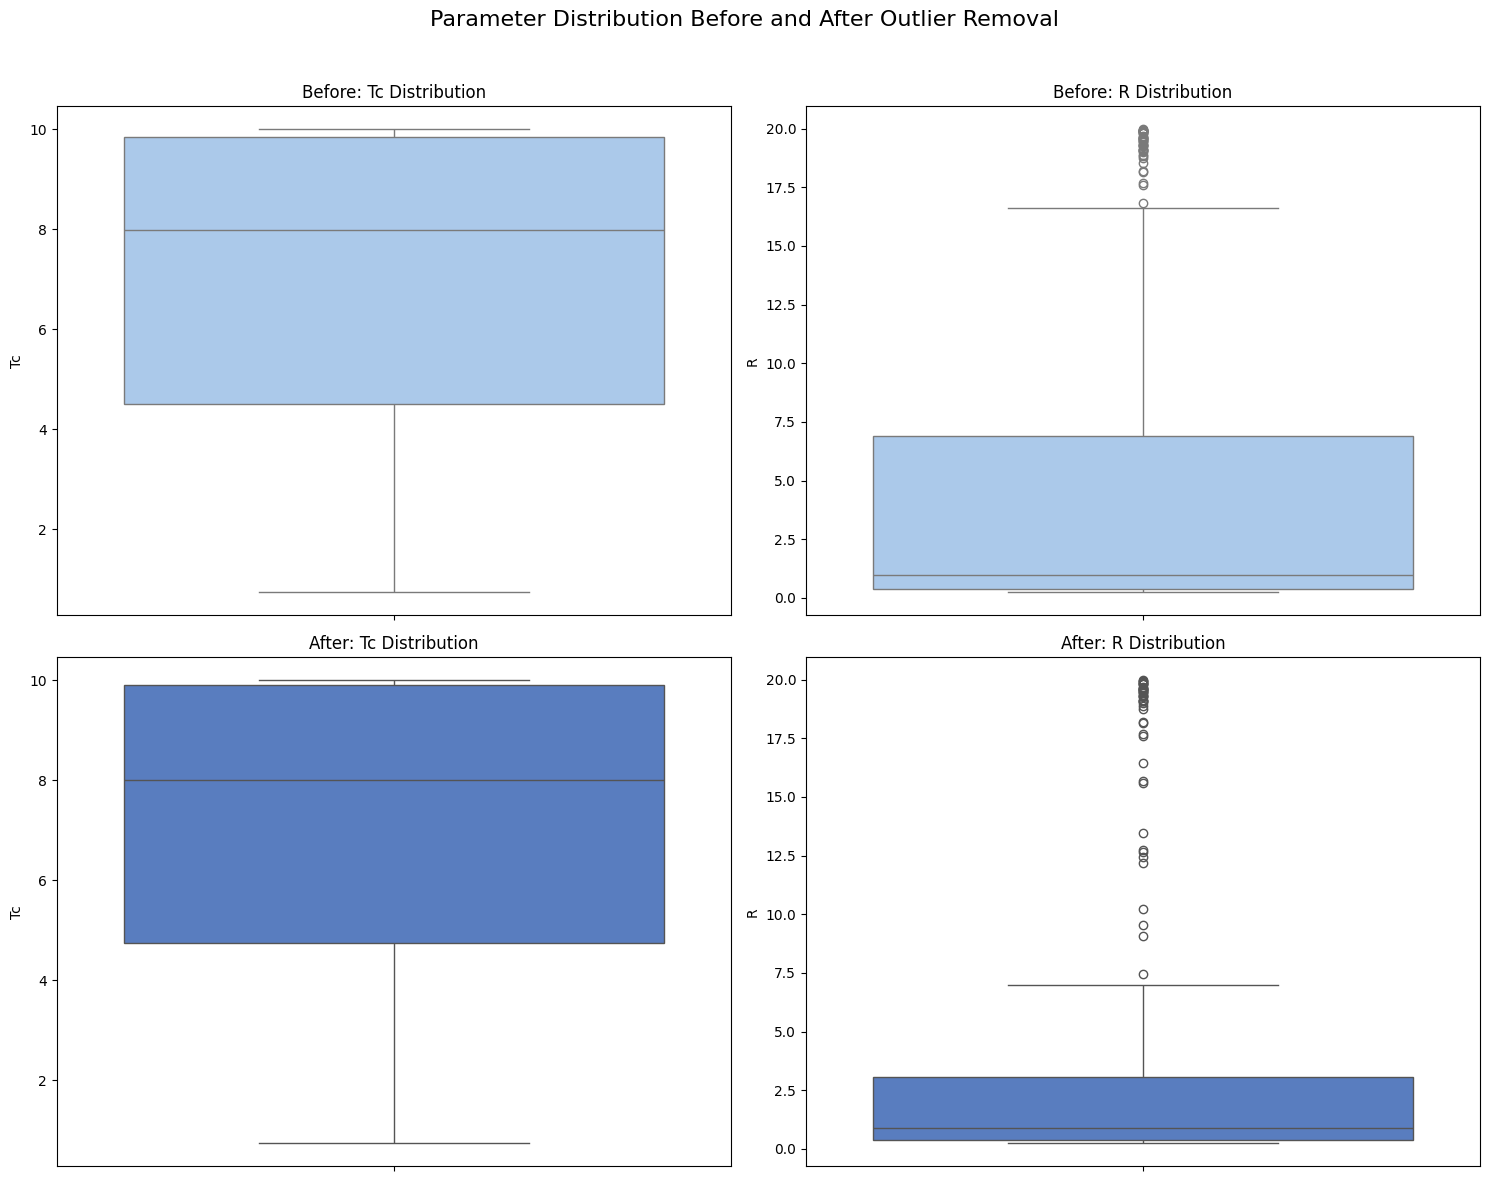

--- After Filtering Watersheds by Event Count ---
Final number of events for analysis: 47
Final number of watersheds with >= 5 events: 8
Total watersheds removed due to low event count: 102




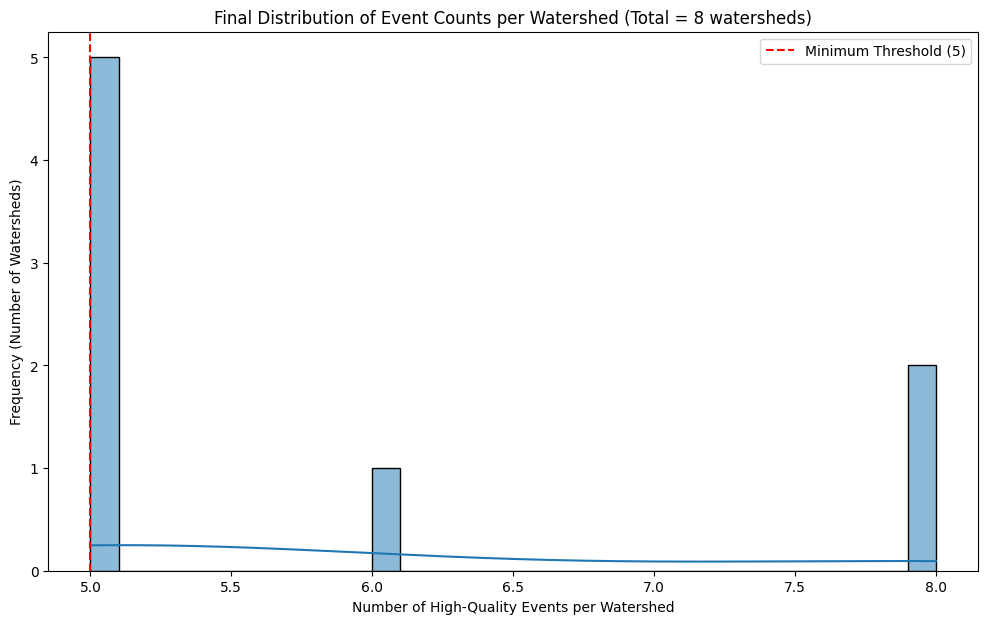

Data cleaning and filtering step is complete.
The resulting DataFrame 'df_filtered' is ready for the next step.


In [58]:
import warnings
warnings.filterwarnings("ignore")
#-------------------------------------------------------------------------------
## Step 1: Initial Filtering for High-Quality Events
#-------------------------------------------------------------------------------

NSE_THRESHOLD = 0
# Filter events with acceptable performance (NSE >= NSE_THRESHOLD).
# We will call this the 'candidate' dataset for outlier removal.
df_candidates = df_events[df_events['NSE'] >= NSE_THRESHOLD].copy()

print("--- Initial State (Before Cleaning) ---")
print(f"Number of events with NSE > {NSE_THRESHOLD}: {len(df_candidates)}")
print(f"Number of watersheds with at least one event: {df_candidates['ws_id'].nunique()}")
print("\n")


#-------------------------------------------------------------------------------
## Step 2: Removing Outliers using the IQR Method per Watershed
#-------------------------------------------------------------------------------

def remove_outliers_iqr(group):
    """
    Applies the IQR outlier removal method to the Tc and R columns of a dataframe group.
    An event is removed if it's an outlier for EITHER Tc or R.
    """
    # Calculate IQR for Tc
    Q1_tc = group['Tc'].quantile(0.25)
    Q3_tc = group['Tc'].quantile(0.75)
    IQR_tc = Q3_tc - Q1_tc
    lower_bound_tc = Q1_tc - 1.5 * IQR_tc
    upper_bound_tc = Q3_tc + 1.5 * IQR_tc

    # Calculate IQR for R
    Q1_r = group['R'].quantile(0.25)
    Q3_r = group['R'].quantile(0.75)
    IQR_r = Q3_r - Q1_r
    lower_bound_r = Q1_r - 1.5 * IQR_r
    upper_bound_r = Q3_r + 1.5 * IQR_r

    # Filter the group
    filtered_group = group[
        (group['Tc'] >= lower_bound_tc) & (group['Tc'] <= upper_bound_tc) &
        (group['R'] >= lower_bound_r) & (group['R'] <= upper_bound_r)
    ]
    return filtered_group

# Apply the function to each watershed group
# Note: The group_keys=False prevents the ws_id from becoming the index.
df_no_outliers = df_candidates.groupby('ws_id',group_keys=False).apply(remove_outliers_iqr)

print("--- After Outlier Removal ---")
print(f"Number of events remaining after outlier removal: {len(df_no_outliers)}")
print(f"Number of watersheds remaining: {df_no_outliers['ws_id'].nunique()}")
print(f"Total events removed as outliers: {len(df_candidates) - len(df_no_outliers)}")
print("\n")


# --- Visualization 1: Before and After Outlier Removal ---
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Parameter Distribution Before and After Outlier Removal', fontsize=16)

# Before
sns.boxplot(data=df_candidates, y='Tc', ax=axes[0, 0], palette='pastel')
axes[0, 0].set_title('Before: Tc Distribution')
sns.boxplot(data=df_candidates, y='R', ax=axes[0, 1], palette='pastel')
axes[0, 1].set_title('Before: R Distribution')

# After
sns.boxplot(data=df_no_outliers, y='Tc', ax=axes[1, 0], palette='muted')
axes[1, 0].set_title('After: Tc Distribution')
sns.boxplot(data=df_no_outliers, y='R', ax=axes[1, 1], palette='muted')
axes[1, 1].set_title('After: R Distribution')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


#-------------------------------------------------------------------------------
## Step 3: Excluding Watersheds with Fewer than 5 Events
#-------------------------------------------------------------------------------

# Calculate the number of events per watershed in the cleaned dataframe
event_counts = df_no_outliers.groupby('ws_id')['ws_id'].transform('size')

# Filter out watersheds with fewer than 5 events
MINIMUM_EVENTS = 5
df_filtered = df_no_outliers[event_counts >= MINIMUM_EVENTS]

print("--- After Filtering Watersheds by Event Count ---")
print(f"Final number of events for analysis: {len(df_filtered)}")
print(f"Final number of watersheds with >= {MINIMUM_EVENTS} events: {df_filtered['ws_id'].nunique()}")
print(f"Total watersheds removed due to low event count: {df_no_outliers['ws_id'].nunique() - df_filtered['ws_id'].nunique()}")
print("\n")

# --- Visualization 2: Final Distribution of Event Counts per Watershed ---
plt.figure(figsize=(12, 7))
final_counts = df_filtered.groupby('ws_id').size()
sns.histplot(final_counts, bins=30, kde=True)
plt.title(f'Final Distribution of Event Counts per Watershed (Total = {len(final_counts)} watersheds)')
plt.xlabel('Number of High-Quality Events per Watershed')
plt.ylabel('Frequency (Number of Watersheds)')
plt.axvline(MINIMUM_EVENTS, color='red', linestyle='--', label=f'Minimum Threshold ({MINIMUM_EVENTS})')
plt.legend()
plt.show()


# The final, cleaned DataFrame is df_filtered
print("Data cleaning and filtering step is complete.")
print("The resulting DataFrame 'df_filtered' is ready for the next step.")

### 3. Ivestigating Temporal Trends

--- Preparing Land Cover Data ---
Land cover data aggregated and processed.

--- Preparing and Merging Event Data ---
Merged dataframe created with 43 events.

--- Performing Statistical Analysis for Each Watershed ---
Statistical analysis complete.

--- Summary of Temporal Trend Analysis ---
      ws_id  anova_p_value_tc  anova_p_value_r  corr_coeff_tc  \
0  03201405          0.719357         0.345592       0.151722   
1  03238140          0.856773         0.352954            NaN   
2  03254693          0.107043         0.057591      -0.406527   
3  03292500          0.189365         0.908045            NaN   
4  03301940          0.927824         0.771932      -0.170751   

   corr_p_value_tc  corr_coeff_r  corr_p_value_r  significant_tc  \
0         0.848278      0.070801        0.929199           False   
1              NaN           NaN             NaN           False   
2         0.497027      0.108337        0.862332           False   
3              NaN           NaN           

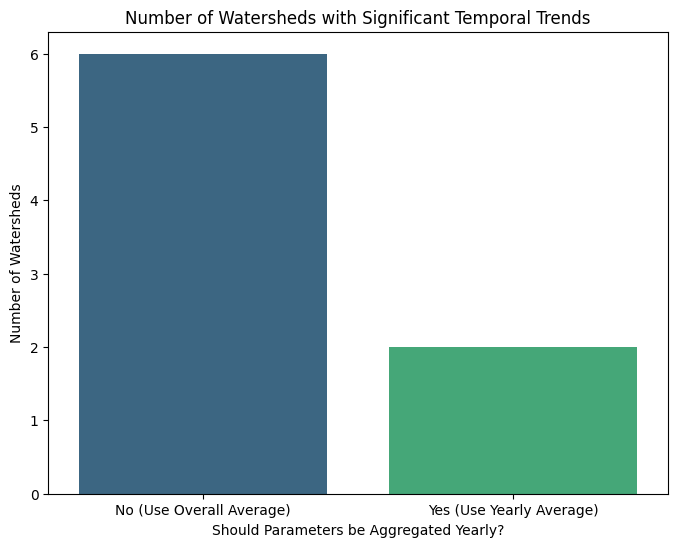


Analysis of temporal trends is complete.
The 'df_analysis' DataFrame contains the decision for each watershed.


In [59]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# df_filtered: From the previous step, containing 'ws_id', 'Tc', 'R', 'event_start'
# df_land_cover: Contains 'ws_id', 'year', and 'lc_code_...' columns

#-------------------------------------------------------------------------------
## Step 1: Prepare Land Cover Data
#-------------------------------------------------------------------------------
print("--- Preparing Land Cover Data ---")

# Define the aggregation mapping
lc_aggregation_map = {
    'Developed': [21, 22, 23, 24],
    'Forest': [41, 42, 43],
    'Agriculture': [81, 82],
    'Grass/Scrub': [52, 71],
    'Wetlands': [90, 95],
    'Water': [11],
    'Barren': [31]
}

# Aggregate the land cover codes
for category, codes in lc_aggregation_map.items():
    lc_cols = [f'lc_code_{code}' for code in codes]
    df_land_cover[category] = df_land_cover[lc_cols].sum(axis=1)

# Calculate total area for percentage calculation (excluding No Data/Unknown)
all_lc_cols = [f'lc_code_{code}' for code_list in lc_aggregation_map.values() for code in code_list]
df_land_cover['total_area'] = df_land_cover[all_lc_cols].sum(axis=1)

# Calculate percentage for the most impactful category: Developed
# Avoid division by zero if total_area is 0
df_land_cover['pct_developed'] = np.where(
    df_land_cover['total_area'] > 0,
    df_land_cover['Developed'] / df_land_cover['total_area'] * 100,
    0
)

# Create a clean, yearly land cover dataframe
df_lc_yearly = df_land_cover[['ws_id', 'year', 'pct_developed']].copy()
print("Land cover data aggregated and processed.\n")


#-------------------------------------------------------------------------------
## Step 2: Prepare and Merge Event Data
#-------------------------------------------------------------------------------
print("--- Preparing and Merging Event Data ---")

# Ensure event_start is a datetime object and extract year
df_filtered['event_start'] = pd.to_datetime(df_filtered['event_start'])
df_filtered['year'] = df_filtered['event_start'].dt.year

# Merge event data with yearly land cover data
df_merged = pd.merge(df_filtered, df_lc_yearly, on=['ws_id', 'year'], how='left')

# Drop events where land cover data was not available for that year
df_merged.dropna(subset=['pct_developed'], inplace=True)
print(f"Merged dataframe created with {len(df_merged)} events.\n")


#-------------------------------------------------------------------------------
## Step 3: Perform Statistical Analysis per Watershed
#-------------------------------------------------------------------------------
print("--- Performing Statistical Analysis for Each Watershed ---")

analysis_results = []
# Get list of watersheds that have data for more than one year
watersheds_to_analyze = df_merged.groupby('ws_id').filter(lambda x: x['year'].nunique() > 1)['ws_id'].unique()

for ws_id in watersheds_to_analyze:
    ws_data = df_merged[df_merged['ws_id'] == ws_id]

    # --- ANOVA Test ---
    # Prepare data for ANOVA: list of arrays, one array of Tc/R values per year
    yearly_groups_tc = [group['Tc'].values for name, group in ws_data.groupby('year')]
    yearly_groups_r = [group['R'].values for name, group in ws_data.groupby('year')]

    # Run ANOVA only if there are at least 2 years of data
    p_anova_tc = stats.f_oneway(*yearly_groups_tc).pvalue if len(yearly_groups_tc) >= 2 else None
    p_anova_r = stats.f_oneway(*yearly_groups_r).pvalue if len(yearly_groups_r) >= 2 else None

    # --- Correlation Analysis ---
    # Aggregate data to yearly means for correlation
    yearly_summary = ws_data.groupby('year').agg(
        mean_tc=('Tc', 'mean'),
        mean_r=('R', 'mean'),
        pct_developed=('pct_developed', 'first') # 'first' is fine since it's constant within the year
    ).reset_index()

    # Run correlation only if there are at least 3 years of data
    if len(yearly_summary) >= 3:
        corr_tc = stats.pearsonr(yearly_summary['pct_developed'], yearly_summary['mean_tc'])
        corr_r = stats.pearsonr(yearly_summary['pct_developed'], yearly_summary['mean_r'])
    else:
        corr_tc = (np.nan, np.nan)
        corr_r = (np.nan, np.nan)

    analysis_results.append({
        'ws_id': ws_id,
        'anova_p_value_tc': p_anova_tc,
        'anova_p_value_r': p_anova_r,
        'corr_coeff_tc': corr_tc[0],
        'corr_p_value_tc': corr_tc[1],
        'corr_coeff_r': corr_r[0],
        'corr_p_value_r': corr_r[1]
    })

df_analysis = pd.DataFrame(analysis_results)

# --- Determine if aggregation should be by year ---
SIGNIFICANCE_LEVEL = 0.05
df_analysis['significant_tc'] = (df_analysis['anova_p_value_tc'] < SIGNIFICANCE_LEVEL) | (df_analysis['corr_p_value_tc'] < SIGNIFICANCE_LEVEL)
df_analysis['significant_r'] = (df_analysis['anova_p_value_r'] < SIGNIFICANCE_LEVEL) | (df_analysis['corr_p_value_r'] < SIGNIFICANCE_LEVEL)
df_analysis['aggregate_by_year'] = df_analysis['significant_tc'] | df_analysis['significant_r']

print("Statistical analysis complete.\n")


#-------------------------------------------------------------------------------
## Step 4: Summarize and Visualize Results
#-------------------------------------------------------------------------------
print("--- Summary of Temporal Trend Analysis ---")
print(df_analysis.head())
print("\n")

summary_counts = df_analysis['aggregate_by_year'].value_counts()
print("Decision on how to aggregate parameters:")
print(summary_counts)

# --- Visualization ---
plt.figure(figsize=(8, 6))
sns.countplot(x='aggregate_by_year', data=df_analysis, palette='viridis')
plt.title('Number of Watersheds with Significant Temporal Trends')
plt.xlabel('Should Parameters be Aggregated Yearly?')
plt.ylabel('Number of Watersheds')
plt.xticks([False, True], ['No (Use Overall Average)', 'Yes (Use Yearly Average)'])
plt.show()

# The final outputs are df_analysis and df_merged, which will be used in the next step.
print("\nAnalysis of temporal trends is complete.")
print("The 'df_analysis' DataFrame contains the decision for each watershed.")

### 4. Final Data Aggregation

--- Separating Watersheds for Aggregation ---
Watersheds to be aggregated yearly: 2
Watersheds to be aggregated with an overall average: 6

--- Processing Yearly-Aggregated Watersheds ---
Original watershed-year groups: 7
Watershed-year groups after CV filter: 6
Groups discarded due to high CV: 1

--- Processing Overall-Aggregated Watersheds ---
Original watersheds in this group: 6
Watersheds after CV filter: 0
Watersheds discarded due to high CV: 6

--- Creating Final Master Dataset ---
Final Master DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ws_id          6 non-null      object 
 1   year           6 non-null      int64  
 2   Tc             6 non-null      float64
 3   R              6 non-null      float64
 4   pct_developed  5 non-null      float64
dtypes: float64(3), int64(1), object(1)
memory usage: 372.0+ bytes

Fi

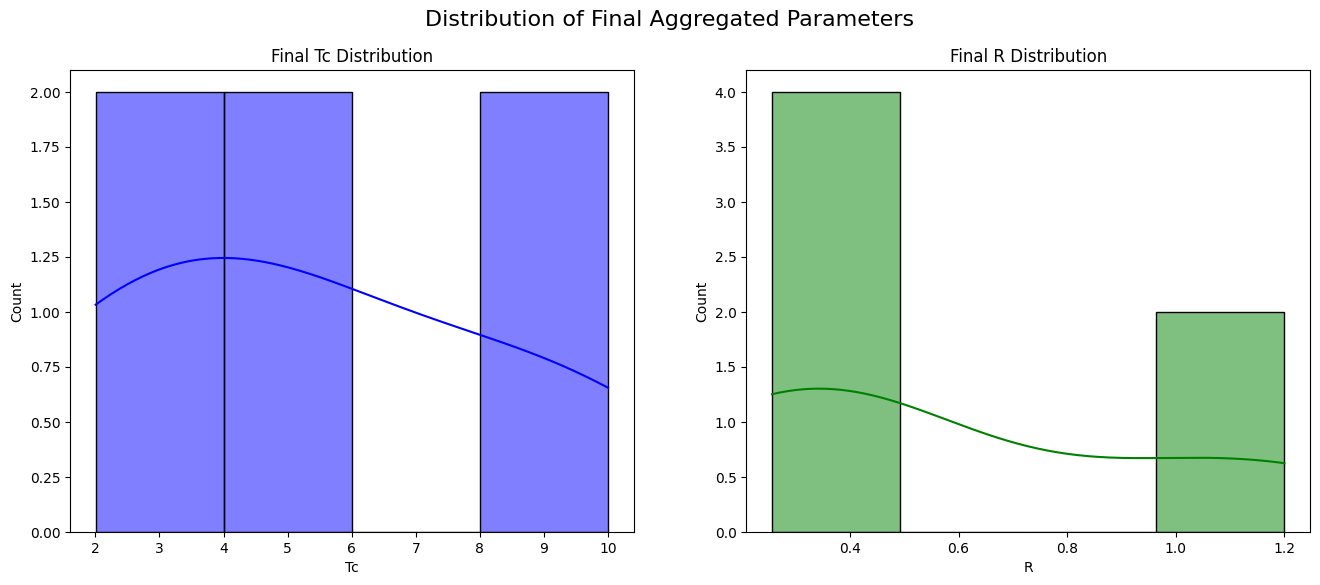

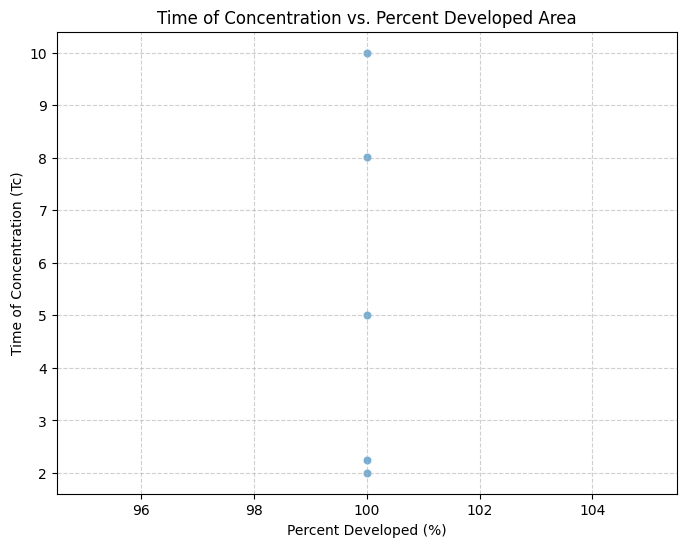


Analysis complete. The 'df_master' DataFrame is ready for machine learning.


In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Assume df_filtered, df_analysis, and df_lc_yearly are pre-existing DataFrames ---
# df_filtered: The cleaned event data (NSE >= NSE_THRESHOLD, outliers removed, etc.).
# df_analysis: The results from the temporal analysis, containing the 'aggregate_by_year' flag.
# df_lc_yearly: The prepared yearly land cover data with 'pct_developed'.

# Define the CV threshold for filtering
CV_THRESHOLD = 0.5

#-------------------------------------------------------------------------------
## Step 1: Separate Watersheds Based on a Temporal Trend Analysis
#-------------------------------------------------------------------------------
print("--- Separating Watersheds for Aggregation ---")

# Get the list of watersheds to aggregate yearly vs. overall
ws_agg_yearly = df_analysis[df_analysis['aggregate_by_year'] == True]['ws_id'].unique()
ws_agg_overall = df_analysis[df_analysis['aggregate_by_year'] == False]['ws_id'].unique()

print(f"Watersheds to be aggregated yearly: {len(ws_agg_yearly)}")
print(f"Watersheds to be aggregated with an overall average: {len(ws_agg_overall)}\n")


#-------------------------------------------------------------------------------
## Step 2: Process Watersheds Requiring Yearly Aggregation
#-------------------------------------------------------------------------------
print("--- Processing Yearly-Aggregated Watersheds ---")

# Filter the events for this group
df_yearly_candidates = df_filtered[df_filtered['ws_id'].isin(ws_agg_yearly)]

# Group by watershed and year to calculate CV
grouped_yearly = df_yearly_candidates.groupby(['ws_id', 'year'])
cv_yearly = grouped_yearly.agg(
    cv_tc=('Tc', lambda x: np.std(x) / np.mean(x)),
    cv_r=('R', lambda x: np.std(x) / np.mean(x))
).reset_index()

# Identify valid groups that pass the CV check
valid_yearly_groups = cv_yearly[
    (cv_yearly['cv_tc'] < CV_THRESHOLD) & (cv_yearly['cv_r'] < CV_THRESHOLD)
][['ws_id', 'year']]

# Filter the original candidates to keep only the valid groups
df_yearly_final_events = pd.merge(df_yearly_candidates, valid_yearly_groups, on=['ws_id', 'year'], how='inner')

# Aggregate the valid groups to get the final mean values
yearly_aggregated = df_yearly_final_events.groupby(['ws_id', 'year']).agg(
    Tc=('Tc', 'mean'),
    R=('R', 'mean')
).reset_index()

# Merge with land cover data to add features
df_final_yearly = pd.merge(yearly_aggregated, df_lc_yearly, on=['ws_id', 'year'], how='left')

print(f"Original watershed-year groups: {len(cv_yearly)}")
print(f"Watershed-year groups after CV filter: {len(df_final_yearly)}")
print(f"Groups discarded due to high CV: {len(cv_yearly) - len(df_final_yearly)}\n")

#-------------------------------------------------------------------------------
## Step 3: Process Watersheds Requiring Overall Aggregation
#-------------------------------------------------------------------------------
print("--- Processing Overall-Aggregated Watersheds ---")

# Filter the events for this group
df_overall_candidates = df_filtered[df_filtered['ws_id'].isin(ws_agg_overall)]

# Group by watershed to calculate CV
grouped_overall = df_overall_candidates.groupby('ws_id')
cv_overall = grouped_overall.agg(
    cv_tc=('Tc', lambda x: np.std(x) / np.mean(x)),
    cv_r=('R', lambda x: np.std(x) / np.mean(x))
).reset_index()

# Identify valid watersheds that pass the CV check
valid_overall_ws = cv_overall[
    (cv_overall['cv_tc'] < CV_THRESHOLD) & (cv_overall['cv_r'] < CV_THRESHOLD)
]['ws_id']

# Aggregate the valid watersheds to get the final mean values
overall_aggregated = df_overall_candidates[df_overall_candidates['ws_id'].isin(valid_overall_ws)].groupby('ws_id').agg(
    Tc=('Tc', 'mean'),
    R=('R', 'mean')
).reset_index()

# To add land use features, we'll use the MOST RECENT land cover data for each watershed
latest_lc = df_lc_yearly.loc[df_lc_yearly.groupby('ws_id')['year'].idxmax()]
df_final_overall = pd.merge(overall_aggregated, latest_lc, on='ws_id', how='left')


print(f"Original watersheds in this group: {len(ws_agg_overall)}")
print(f"Watersheds after CV filter: {len(df_final_overall)}")
print(f"Watersheds discarded due to high CV: {len(ws_agg_overall) - len(df_final_overall)}\n")


#-------------------------------------------------------------------------------
## Step 4: Combine into Final Master DataFrame and Summarize
#-------------------------------------------------------------------------------
print("--- Creating Final Master Dataset ---")

# Concatenate the two final dataframes
df_master = pd.concat([df_final_yearly, df_final_overall], ignore_index=True)

print("Final Master DataFrame Info:")
df_master.info()
print("\nFinal Master DataFrame Description:")
print(df_master.describe())


# --- Visualization of Final Dataset ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distribution of Final Aggregated Parameters', fontsize=16)

sns.histplot(df_master['Tc'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Final Tc Distribution')

sns.histplot(df_master['R'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Final R Distribution')

plt.show()

# --- Visualization of Relationships ---
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_master, x='pct_developed', y='Tc', alpha=0.6)
plt.title('Time of Concentration vs. Percent Developed Area')
plt.xlabel('Percent Developed (%)')
plt.ylabel('Time of Concentration (Tc)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("\nAnalysis complete. The 'df_master' DataFrame is ready for machine learning.")